<a href="https://colab.research.google.com/github/Irfanmaulanaaa102/ANALISIS-SENTIMEN-BEA-CUKAI/blob/main/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import csv
import nltk
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemover, ArrayDictionary
import string
from google.colab import files
import ftfy



In [ ]:
!pip install Sastrawi
!pip install ftfy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df = pd.read_csv("/content/beacukai_(2025).csv")


In [ ]:
df = df[['full_text', 'created_at']]
df

,full_text,created_at
0,Kepala Kantor Bea Cukai Bekasi Yanti Sarmuhida...,Wed Jan 22 09:03:55 +0000 2025
1,Bea Cukai Berulah Lagiâ¼ï¸ Lah lupa apa kema...,Tue Jan 28 07:12:17 +0000 2025
2,Kira kira Bea cukai melakukan ini atas perinta...,Sat Jan 25 05:43:09 +0000 2025
3,Iphone 16 128 gb inter + bea cukai brand new s...,Mon Jan 27 12:50:49 +0000 2025
4,WTS Iphone 12 mini black 64gb Wifi Only Ready!...,Sun Jan 26 06:20:15 +0000 2025
...,...,...
13596,Tidak ada petugas Bea Cukai dan petugas Imigra...,Tue Dec 02 08:38:07 +0000 2025
13597,@hfbrjcmfkw91571 @indramadong @Secretnesia24 K...,Tue Dec 02 08:29:18 +0000 2025
13598,@theothentic Alhamdulillah udah lewat dari Bea...,Tue Dec 02 08:24:44 +0000 2025
13599,@Secretnesia24 Pegawai bea cukai mikirin rakya...,Tue Dec 02 08:24:40 +0000 2025


In [ ]:
df.shape

(819, 2)

### REMOVE DUPLICATES

Proses penghapusan data duplikat cukup dilakukan menggunakan fungsi bernama drop_duplicates dari library pandas yang sudah tersedia

In [ ]:
df = df.drop_duplicates(subset=['full_text'])

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
full_text,0
created_at,0


### **FILTERING/CLEANING**

dilakukan dengan menyingkirkan elemen – elemen yang tidak relevan dari data teks, seperti elemen mention (@), hashtag (#), indikator retweet (RT), url (https), angka, dan blank space atau spasi yang berlebih


In [ ]:


def filtering_text(text):
    # perbaiki encoding bermasalah (Ã Â¸ dll)
    text = ftfy.fix_text(text)

    # ubah ke huruf kecil
    text = text.lower()

    # hapus url
    text = re.sub(r'https?:\/\/\S+', '', text)

    # hapus mention, hashtag, link
    text = ' '.join(
        re.sub(r'([@#][A-Za-z0-9_]+)|(\w+:\/\/\S+)', ' ', text).split()
    )

    # hapus byte string (b')
    text = re.sub(r"(b'{1,2})", "", text)

    # hapus karakter non-huruf (hanya a-z)
    text = re.sub(r'[^a-z]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['filtered'] =df['full_text'].apply(filtering_text)
print(df['filtered'].head())

0    kepala kantor bea cukai bekasi yanti sarmuhida...
1    bea cukai berulah lagi lah lupa apa kemaren ad...
2    kira kira bea cukai melakukan ini atas perinta...
3    iphone gb inter bea cukai brand new sisa khusu...
4    wts iphone mini black gb wifi only ready healt...
Name: filtered, dtype: object


In [ ]:
output_path = ("normalisasi.csv")
df.to_csv(output_path, index=False, encoding='utf-8')


### **CASEFOLDING**

Case Folding dilakukan dengan mengubah huruf besar (uppercase) pada kalimat menjadi huruf kecil (lowercase).

In [ ]:
df.loc[:, 'full_text'] = df['full_text'].str.lower()


In [ ]:
df

,full_text,created_at,filtered
0,kemenhub mencabut izin internasional bandara i...,Sat Nov 29 23:58:21 +0000 2025,kemenhub mencabut izin internasional bandara i...
1,@henrysubiakto tapi di berita menurut dirjen p...,Sat Nov 29 23:54:27 +0000 2025,tapi di berita menurut dirjen perhubungan soal...
2,udah kelihatan kok kesaktian mantra pak @prabo...,Sat Nov 29 23:43:23 +0000 2025,udah kelihatan kok kesaktian mantra pak hidup ...
3,@dodisegrovee @worksfess yg perlu dipahami jug...,Sat Nov 29 23:38:17 +0000 2025,yg perlu dipahami juga bahwa skup pekerjaan be...
4,gaduh bandara imip tak ada bea cukai dan imigr...,Sat Nov 29 23:32:24 +0000 2025,gaduh bandara imip tak ada bea cukai dan imigr...
...,...,...,...
815,bea cukai berkolaborasi dengan uptp balai besa...,Thu Nov 27 08:42:03 +0000 2025,bea cukai berkolaborasi dengan uptp balai besa...
816,menkeu benarkan bandara imip tanpa petugas bea...,Thu Nov 27 08:40:51 +0000 2025,menkeu benarkan bandara imip tanpa petugas bea...
817,@balimbingj @dhinda_8 bandara yang hanya melay...,Thu Nov 27 08:38:23 +0000 2025,bandara yang hanya melayani penerbangan lokal ...
818,@bangsaygsujud @prabowo @99propaganda @are_ini...,Thu Nov 27 08:34:33 +0000 2025,inismyname back ps kekurangannya adalah minim ...


In [ ]:
norm = {" se7 ":" setuju ", " prokontra ":" pro dan kontra ", " jangan2 ":" jangan - jangan "," gak ":" tidak ", " nggak ":" tidak ", " gatau ":" tidak tahu ", " gweh ":" aku ", " gua ":" aku "," tapera ":" tabungan perumahan rakyat ", " krn ":" karena "," ruu ":" rancangan undang - undang ", " ikn ":" ibu kota nusantara "," samasama ":" sama sama ", " grgr ":" gara gara ", " kontropersi ":" kontroversi ", " teman2 ":" teman - teman ", " orang2 ":" orang - orang ", " dipake ":" dipakai ", " tdk ":" tidak ", " trimakasih ":" terima kasih ", " ijin ":" izin ", " ri ":" republik indonesia "," bentar ":" sebentar ", " gaje ":" tidak jelas ", " hiduphidup ":" hidup - hidup ", " anak2 ":"anak - anak ", " pks ":" partai keadilan sejahtera "," asn ":" aparatur sipil negara "," rb ":" ribu "," utk ":" untuk " }
def normalisasi(str_next):
  for i in norm:
    str_text = str_next.replace(i, norm[i])
  return str_text
df['full_text'], df['full_text'].apply(lambda x:normalisasi(x))
df

,full_text,username,created_at
0,mari kita cek kepemilikan tanah amp bangunan p...,aricandra,Sun Jun 02 15:30:18 +0000 2024
1,asabri jiwasraya taspen next tapera koruptor d...,BosPurwa,Tue May 28 15:12:18 +0000 2024
2,kalo gotong royong royong yg jadi pejabat peng...,5teV3n_Pe9eL,Sat Jun 01 21:35:49 +0000 2024
3,pov karyawan menengah ketika gajian tapera tab...,KangManto123,Wed May 29 00:18:48 +0000 2024
4,tapera apa tu guys,tanyarlfes,Mon May 27 11:08:01 +0000 2024
...,...,...,...
2911,tapera itu tabungan rakyat artinya bisa diambi...,hayanaqu,Tue May 28 23:20:31 +0000 2024
2912,tabungan sudah dilakukan lewat bpjs ketenagake...,Indonesiaguyub,Tue May 28 13:53:50 +0000 2024
2913,maaf ijin bertanya tapera itu apakah singkatan...,oxfara,Tue May 28 11:25:50 +0000 2024
2914,tapera tabungan penderitaan rakyat,Presiden_Swasta,Fri May 31 11:04:04 +0000 2024


### STOPWORD REMOVAL & STEMMING


In [ ]:
with open('/content/kamus.txt') as f:
    list_stopword = [line.strip() for line in f]

dictionary = ArrayDictionary(list_stopword)
stopword_remover = StopWordRemover(dictionary)


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()


In [ ]:
def stop_stem(text):
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text


In [ ]:
# Stopword removal + stemming
df['processed'] = df['filtered'].apply(stop_stem)

# Cek hasil


,full_text,processed
0,kemenhub mencabut izin internasional bandara i...,kemenhub cabut izin internasional bandara imip...
1,@henrysubiakto tapi di berita menurut dirjen p...,tapi berita turut dirjen hubung soal bandara k...
2,udah kelihatan kok kesaktian mantra pak @prabo...,udah lihat sakti mantra pak hidup jokowi itu k...
3,@dodisegrovee @worksfess yg perlu dipahami jug...,perlu paham bahwa skup kerja bea cukai skrg cu...
4,gaduh bandara imip tak ada bea cukai dan imigr...,gaduh bandara imip tak ada bea cukai imigrasi ...


In [ ]:
df[['filtered', 'processed']].head()


,filtered,processed
0,kemenhub mencabut izin internasional bandara i...,kemenhub cabut izin internasional bandara imip...
1,tapi di berita menurut dirjen perhubungan soal...,tapi berita turut dirjen hubung soal bandara k...
2,udah kelihatan kok kesaktian mantra pak hidup ...,udah lihat sakti mantra pak hidup jokowi itu k...
3,yg perlu dipahami juga bahwa skup pekerjaan be...,perlu paham bahwa skup kerja bea cukai skrg cu...
4,gaduh bandara imip tak ada bea cukai dan imigr...,gaduh bandara imip tak ada bea cukai imigrasi ...


In [ ]:
def word_tokenize_wrapper(text):
    return word_tokenize(text)

df['tweet_tokens'] = df['processed'].apply(word_tokenize_wrapper)

print(df['tweet_tokens'].head())

0    [kemenhub, cabut, izin, internasional, bandara...
1    [tapi, berita, turut, dirjen, hubung, soal, ba...
2    [udah, lihat, sakti, mantra, pak, hidup, jokow...
3    [perlu, paham, bahwa, skup, kerja, bea, cukai,...
4    [gaduh, bandara, imip, tak, ada, bea, cukai, i...
Name: tweet_tokens, dtype: object


In [ ]:
kamus_normalisasi = pd.read_csv("/content/slang.csv")

kata_normalisasi_dict = {}

for index, row in kamus_normalisasi.iterrows():
    if row[0] not in kata_normalisasi_dict:
        kata_normalisasi_dict[row[0]] = row[1]

def normalisasi_kata(document):
    return [kata_normalisasi_dict[term] if term in kata_normalisasi_dict else term for term in document]

df['normalisasi'] =df['tweet_tokens'].apply(normalisasi_kata)

df['normalisasi'].head(10)

/tmp/ipython-input-2750886883.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[0] not in kata_normalisasi_dict:
/tmp/ipython-input-2750886883.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  kata_normalisasi_dict[row[0]] = row[1]


,normalisasi
0,"[kemenhub, cabut, izin, internasional, bandara..."
1,"[tapi, berita, turut, dirjen, hubung, soal, ba..."
2,"[sudah, lihat, sakti, mantra, bapak, hidup, jo..."
3,"[perlu, paham, bahwa, skup, kerja, bea, cukai,..."
4,"[gaduh, bandara, imip, tidak, ada, bea, cukai,..."
5,"[ri, tniau, tni, imigrasi, airports, kalu, sta..."
6,"[riverheaven, bagus, saling, bongkar, pajak, b..."
7,"[bijak, menkeu, purbaya, yudhi, sadewa, akan, ..."
8,"[deterjen, bea, cukai]"
9,"[tuju, kalau, perlu, impor, luar, negeri, tena..."


In [ ]:
df

,full_text,created_at,filtered,processed,tweet_tokens,normalisasi
0,kemenhub mencabut izin internasional bandara i...,Sat Nov 29 23:58:21 +0000 2025,kemenhub mencabut izin internasional bandara i...,kemenhub cabut izin internasional bandara imip...,"[kemenhub, cabut, izin, internasional, bandara...","[kemenhub, cabut, izin, internasional, bandara..."
1,@henrysubiakto tapi di berita menurut dirjen p...,Sat Nov 29 23:54:27 +0000 2025,tapi di berita menurut dirjen perhubungan soal...,tapi berita turut dirjen hubung soal bandara k...,"[tapi, berita, turut, dirjen, hubung, soal, ba...","[tapi, berita, turut, dirjen, hubung, soal, ba..."
2,udah kelihatan kok kesaktian mantra pak @prabo...,Sat Nov 29 23:43:23 +0000 2025,udah kelihatan kok kesaktian mantra pak hidup ...,udah lihat sakti mantra pak hidup jokowi itu k...,"[udah, lihat, sakti, mantra, pak, hidup, jokow...","[sudah, lihat, sakti, mantra, bapak, hidup, jo..."
3,@dodisegrovee @worksfess yg perlu dipahami jug...,Sat Nov 29 23:38:17 +0000 2025,yg perlu dipahami juga bahwa skup pekerjaan be...,perlu paham bahwa skup kerja bea cukai skrg cu...,"[perlu, paham, bahwa, skup, kerja, bea, cukai,...","[perlu, paham, bahwa, skup, kerja, bea, cukai,..."
4,gaduh bandara imip tak ada bea cukai dan imigr...,Sat Nov 29 23:32:24 +0000 2025,gaduh bandara imip tak ada bea cukai dan imigr...,gaduh bandara imip tak ada bea cukai imigrasi ...,"[gaduh, bandara, imip, tak, ada, bea, cukai, i...","[gaduh, bandara, imip, tidak, ada, bea, cukai,..."
...,...,...,...,...,...,...
815,bea cukai berkolaborasi dengan uptp balai besa...,Thu Nov 27 08:42:03 +0000 2025,bea cukai berkolaborasi dengan uptp balai besa...,bea cukai kolaborasi dengan uptp balai besar l...,"[bea, cukai, kolaborasi, dengan, uptp, balai, ...","[bea, cukai, kolaborasi, dengan, uptp, balai, ..."
816,menkeu benarkan bandara imip tanpa petugas bea...,Thu Nov 27 08:40:51 +0000 2025,menkeu benarkan bandara imip tanpa petugas bea...,menkeu benar bandara imip tanpa tugas bea cuka...,"[menkeu, benar, bandara, imip, tanpa, tugas, b...","[menkeu, benar, bandara, imip, tanpa, tugas, b..."
817,@balimbingj @dhinda_8 bandara yang hanya melay...,Thu Nov 27 08:38:23 +0000 2025,bandara yang hanya melayani penerbangan lokal ...,bandara hanya layan terbang lokal tidak perlu ...,"[bandara, hanya, layan, terbang, lokal, tidak,...","[bandara, hanya, layan, terbang, lokal, tidak,..."
818,@bangsaygsujud @prabowo @99propaganda @are_ini...,Thu Nov 27 08:34:33 +0000 2025,inismyname back ps kekurangannya adalah minim ...,inismyname back ps kurang adalah minim perangk...,"[inismyname, back, ps, kurang, adalah, minim, ...","[inismyname, kembali, ps, kurang, adalah, mini..."


In [ ]:
df.to_csv(output_path, index=False, encoding='utf-8')

output_path = ("filtering.csv")

NameError: name 'output_path' is not defined

In [ ]:
files.download = output_path

In [ ]:
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_words = ["tidak"]
stop_words = StopWordRemoverFactory().get_stop_words()
stop_words.extend(more_stop_words)
new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopword(str_text):
  str_text = stop_words_remover_new.remove(str_text)
  return str_text
df ['full_text'] = df['full_text'].apply(lambda x: stopword(x))
df.head()

,full_text,username,created_at
0,kita cek kepemilikan tanah amp bangunan pejaba...,aricandra,Sun Jun 02 15:30:18 +0000 2024
1,asabri jiwasraya taspen next tapera koruptor d...,BosPurwa,Tue May 28 15:12:18 +0000 2024
2,kalo gotong royong royong yg jadi pejabat peng...,5teV3n_Pe9eL,Sat Jun 01 21:35:49 +0000 2024
3,pov karyawan menengah gajian tapera tabungan p...,KangManto123,Wed May 29 00:18:48 +0000 2024
4,tapera apa tu guys,tanyarlfes,Mon May 27 11:08:01 +0000 2024


In [ ]:
tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

0       [mari, kita, cek, kepemilikan, tanah, amp, ban...
1       [asabri, jiwasraya, taspen, next, tapera, koru...
2       [kalo, gotong, royong, royong, yg, jadi, pejab...
3       [pov, karyawan, menengah, ketika, gajian, tape...
4                                 [tapera, apa, tu, guys]
                              ...                        
2911    [tapera, itu, tabungan, rakyat, artinya, bisa,...
2912    [tabungan, sudah, dilakukan, lewat, bpjs, kete...
2913    [maaf, ijin, bertanya, tapera, itu, apakah, si...
2914              [tapera, tabungan, penderitaan, rakyat]
2915    [tapera, potonganehtabungan, untuk, rakyat, me...
Name: full_text, Length: 2915, dtype: object

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def stemming(text_cleaning):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  do = []
  for w in text_cleaning:
    dt = stemmer.stem(w)
    do.append(dt)
  d_clean = []
  d_clean = " ".join(do)
  print(d_clean)
  return d_clean
tokenized = tokenized.apply(stemming)
tokenized.to_csv('tokenized.csv', index=False)

mari kita cek milik tanah amp bangun para jabat yg libat atau promosi tapera gen x komite sri mulyani lhkpn 2023 11 unit tanah amp bangun total nilai rp49 m total luas tanahbangunan 2768 m2 basuki 2023 8 unit rp16 3 m total luas
asabri jiwasraya taspen next tapera koruptor demen bat yg begini
kalo gotong royong royong yg jadi jabat kelola tapera seharusnta sukarela tak gaji betul atau tidak
pov karyawan tengah ketika gaji tapera tabung peras rakyat
tapera apa tu guys
guys keluarga udah punya rumah dari 10 tahun lalu tapi atur tapera ini tuh juga harus ikut kayak ngga ada program guna aja deh sender mau kuliah soal ngga ada niat demo gitu kah guys perintah ngemisnya makin menjadijadi lho
untuk apa tapera kalau udah punya rumah mobil dan aset tidak perlu apa gak ada fungsi tapera ini
malming yang twtw aja tapera livin selesai di doggy on sosmed besok senin
taktik gorong2 nyelinap ketika semua sibuk
saya tarik dengan jelas bapak ini kita ulas satu2 jawab agak panjang ulas tanya pertama ma

In [ ]:
data = pd.read_csv('/content/tokenized.csv')
data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/tokenized.csv'

In [ ]:
!pip install deep-translator


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.9 MB/s eta 0:00:00


In [ ]:
from deep_translator import GoogleTranslator
import time

# Membaca file CSV
df = pd.read_csv('/content/tokenized.csv')

# Inisialisasi penerjemah
translator = GoogleTranslator(source='id', target='en')

# Fungsi untuk menerjemahkan teks
def translate_text(text):
    try:
        return translator.translate(text)
    except Exception as e:
        print(f"Error translating {text}: {e}")
        return text

# Kolom yang akan diterjemahkan
column_to_translate = 'full_text'  # Ganti dengan nama kolom yang sesuai

# Batch processing
batch_size = 100
for start in range(0, len(df), batch_size):
    end = start + batch_size
    df.loc[start:end, column_to_translate] = df.loc[start:end, column_to_translate].apply(translate_text)
    print(f"Translated rows {start} to {end}")
    time.sleep(60)  # Jeda 60 detik antara batch untuk menghindari batasan

# Menyimpan hasil ke file CSV baru
df.to_csv('output.csv', index=False)

print("Penerjemahan selesai dan disimpan ke 'output.csv'")


Error translating nan: nan --> text must be a valid text with maximum 5000 character,otherwise it cannot be translated
Translated rows 0 to 100
Translated rows 100 to 200
Translated rows 200 to 300
Error translating nan: nan --> text must be a valid text with maximum 5000 character,otherwise it cannot be translated
Translated rows 300 to 400
Error translating nan: nan --> text must be a valid text with maximum 5000 character,otherwise it cannot be translated
Translated rows 400 to 500
Error translating nan: nan --> text must be a valid text with maximum 5000 character,otherwise it cannot be translated
Error translating nan: nan --> text must be a valid text with maximum 5000 character,otherwise it cannot be translated
Translated rows 500 to 600
Error translating nan: nan --> text must be a valid text with maximum 5000 character,otherwise it cannot be translated
Translated rows 600 to 700
Translated rows 700 to 800
Translated rows 800 to 900
Error translating nan: nan --> text must be a

In [ ]:
data = pd.read_csv('/content/hasilterjemahan.csv')
data

,full_text,tweet_english
0,kita cek milik tanah amp bangun jabat yg libat...,we check the ownership of the land & building ...
1,asabri jiwasraya taspen next tapera koruptor d...,Asabri Jiwasraya Taspen Next Tapera Corruptors...
2,kalo gotong royong royong yg jadi jabat kelola...,"If it's mutual cooperation, those in charge of..."
3,pov karyawan tengah gaji tapera tabung peras r...,pov middle employee salary tapera tube squeeze...
4,tapera apa tu guys,"What is a tapera, guys?"
...,...,...
2910,tapera tabung rakyat arti ambil tunai rakyat t...,Tapera savings for the people means taking cas...
2911,tabung laku lewat bpjs ketenagakerjaan harus t...,"selling tubes through BPJS employment, you hav..."
2912,maaf ijin tanya tapera apakah singkat tabung d...,"Sorry, let me ask if Tapera is a short tube of..."
2913,tapera tabung derita rakyat,tapera tube of people's suffering


In [ ]:
!pip install tweet_preprocessor
!pip install textblob
!pip install wordcloud
!pip install nltk

In [ ]:
import preprocessor as p
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# Membaca file CSV

# Mengganti nilai NaN dengan string kosong
data['tweet_english'] = data['tweet_english'].fillna('')

# Mengonversi semua nilai ke string untuk memastikan kompatibilitas dengan TextBlob
data['tweet_english'] = data['tweet_english'].astype(str)

# Menyiapkan variabel untuk analisis sentimen
polaritas = 0
status = []
total_positif = total_negatif = total_netral = total = 0

# Iterasi melalui setiap baris dalam kolom 'tweet_english'
for tweet in data['tweet_english']:
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity
    if analysis.sentiment.polarity > 0.0:
        total_positif += 1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')
    total += 1

# Menambahkan hasil analisis ke DataFrame
data['sentiment'] = status

# Menyimpan hasil ke file CSV baru
data.to_csv('output.csv', index=False)

# Menampilkan hasil analisis
print(f'Hasil analisis data: \nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}')
print(f'\nTotal Data: {total}')

Hasil analisis data: 
Positif = 1234
Netral = 1152
Negatif = 529

Total Data: 2915


In [ ]:
data['klasifikasi'] = status
data
data.to_csv('klasifikasi.csv',index=False)

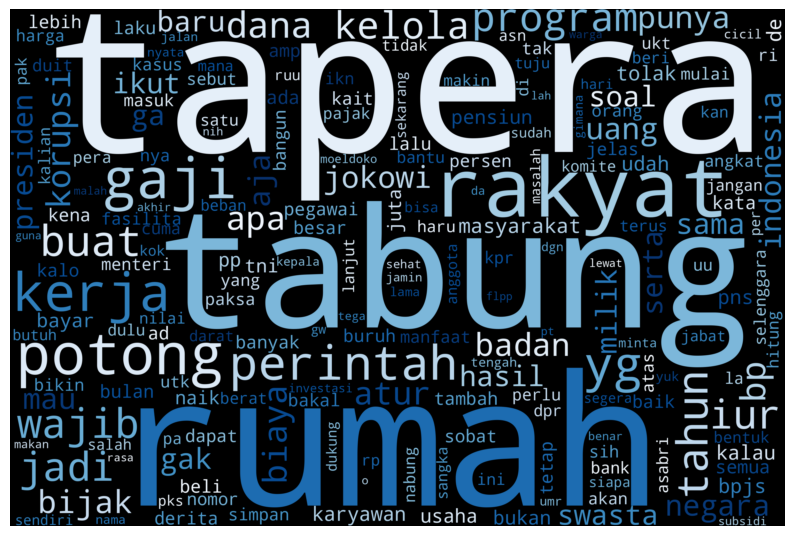

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Fungsi untuk menampilkan wordcloud
def plot_cloud(wordcloud):
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

# Membaca file CSV

# Mengganti nilai NaN dengan string kosong
data['full_text'] = data['full_text'].fillna('')

# Mengonversi semua nilai ke string
data['full_text'] = data['full_text'].astype(str)

# Menggabungkan semua teks dari kolom 'full_text' menjadi satu string
all_words = ' '.join(data['full_text'])

# Membuat wordcloud
wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

# Menampilkan wordcloud
plot_cloud(wordcloud)

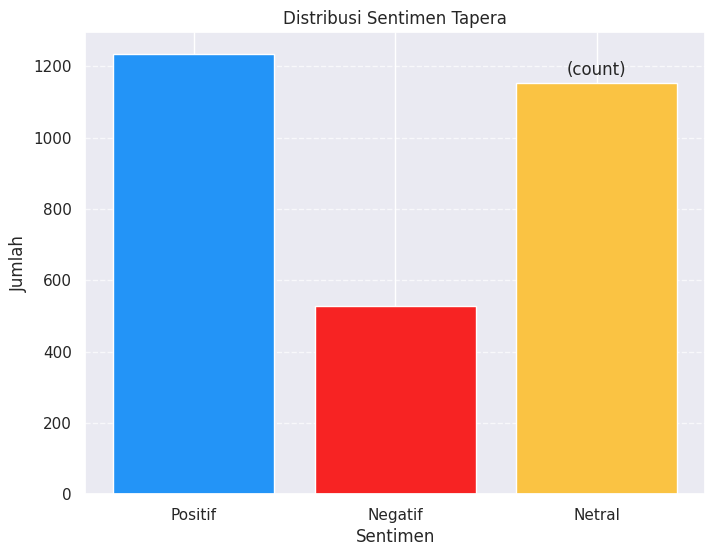

In [ ]:
import seaborn as sns
sns.set_theme()
labels = ['Positif', 'Negatif', 'Netral']
counts = [total_positif, total_negatif, total_netral]
def show_bar_chart(labels, counts, title):
  fig, ax = plt.subplots(figsize=(8, 6))
  bars=ax.bar(labels, counts, color=['#2394f7', '#f72323', '#fac343'])
  for bar, count in zip(bars, counts): height = bar.get_height()
  ax.annotate(f'(count)', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
  textcoords="offset points",
  ha='center', va='bottom')
  ax.grid(axis='y', linestyle='--', alpha=0.7)
  ax.set_xlabel('Sentimen')
  ax.set_ylabel('Jumlah')
  ax.set_title(title)
  plt.show()
show_bar_chart(labels, counts, "Distribusi Sentimen Tapera")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import pandas as pd

# Membaca dataset
data = pd.read_csv('/content/klasifikasi (1).csv')

# Melakukan pemetaan data
data['full_text'].fillna('', inplace=True)  # Mengganti NaN dengan string kosong
data['klasifikasi'].fillna('Tidak Diketahui', inplace=True)  # Mengganti NaN dengan label "Tidak Diketahui"

# Memisahkan fitur dan label
X = data['full_text']
y = data['klasifikasi']

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menggunakan CountVectorizer untuk mengonversi teks menjadi representasi numerik
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Membuat dan melatih model Naive Bayes Multinomial
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)

# Melakukan prediksi terhadap set pengujian
y_pred = clf.predict(X_test_counts)

# Evaluasi model
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Negatif       0.45      0.22      0.30        85
      Netral       0.79      0.46      0.59       237
     Positif       0.55      0.84      0.66       261

    accuracy                           0.60       583
   macro avg       0.60      0.51      0.52       583
weighted avg       0.63      0.60      0.58       583

